# Three-Parameter MCMC: M, Mdot and Cf

This notebook implements a three-parameter MCMC analysis to study accretion processes in transitional blazars using a unified Shakura-Sunyaev (SS) + ADAF framework.

The code reads observed broad emission-line luminosities, builds theoretical accretion spectra for both radiatively efficient and inefficient regimes, and computes the ionizing luminosity associated with each emission line. The modeled line luminosities are then compared with observations through a Bayesian MCMC approach with three free parameters: black hole mass (`M`), accretion rate (`mdot`), and BLR covering factor (`Cf`).

The notebook also evaluates posterior distributions, determines the probability of ADAF and SS accretion regimes, and produces diagnostic plots such as trace plots and corner plots for the posterior analysis.


In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv
import emcee
import corner

# Physical constants in cgs units
c = 2.99792458e10          # Speed of light [cm/s]
G = 6.67430e-8             # Gravitational constant [cm^3 g^-1 s^-2]
h = 6.62607015e-27         # Planck constant [erg s]
kB = 1.380649e-16          # Boltzmann constant [erg/K]
sigma_sb = 5.670374419e-5  # Stefan-Boltzmann constant [erg cm^-2 s^-1 K^-4]
Msun = 1.98847e33          # Solar mass [g]

## Useful functions

- `find_column(df, possible_names, required=True)`  
  Takes as input a dataframe, usually read from `Tab_completa_revisione.csv`, and a list of possible column names.  
  It checks which column identifies the blazar, for example `label`, `file_name`, `name`, `nome`, or `blazar`.  
  It returns the first valid column name found. If no column is found and `required=True`, the function stops the code with an error.

- `read_transitions(transition_file)`  
  Takes as input the transition file `dati.asc`.  
  It reads, for each emission line, the line name, the ionization energy, and the ionization threshold frequency.  
  It returns a dataframe with the columns `line_name`, `E_ion`, and `nu_ion`.

- `extract_observed_lines(row, norm_columns, rel_err)`  
  Takes as input one selected blazar row from `Tab_completa_revisione.csv`, the columns containing line normalizations, and a relative error.  
  It selects only the detected lines with positive normalization, converts the normalization into luminosity using `L_line_obs = norm_value × 10^42 erg/s`, and assigns an uncertainty.  
  If the measured uncertainty is available in `Tab_completa_revisione.csv`, it uses the corresponding `_norm_unc` column; otherwise, it assigns `sigma_L = rel_err × L_line_obs`.  
  It returns a dataframe containing the observed line name, normalization, luminosity, and uncertainty.

- `prepare_blazar_data(label_target, line_file, transition_file, rel_err)`  
  Takes as input the target blazar name, the observational line table `Tab_completa_revisione.csv`, the transition table `dati.asc`, and the relative error.  
  It reads both files, identifies the correct blazar-label column, selects the target blazar, extracts its observed emission lines using `extract_observed_lines()`, and merges them with the ionization information read from `dati.asc`.  
  It returns three dataframes: the full observational table, the transition table, and the final observed-line dataframe used in the likelihood calculation.

In [200]:
def find_column(df, possible_names, required=True):
    for name in possible_names:
        if name in df.columns:
            return name

    if required:
        raise ValueError(f"None of these columns were found: {possible_names}")

    return None


def read_transitions(transition_file):
    names, Eion, nu_ion_list = np.genfromtxt(
        transition_file,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def extract_observed_lines(row, norm_columns, rel_err):
    results = []

    for col in norm_columns:
        value = row[col]

        if pd.isna(value) or value <= 0:
            continue

        line_name = col.replace("_norm", "")
        unc_col = f"{line_name}_norm_unc"

        L_line = value * 1e42

        if unc_col in row.index and pd.notna(row[unc_col]) and row[unc_col] > 0:
            sigma_L = row[unc_col] * 1e42
        else:
            sigma_L = rel_err * L_line

        results.append({
            "line_name": line_name,
            "norm_value": value,
            "L_line_obs": L_line,
            "sigma_L": sigma_L
        })

    return pd.DataFrame(results)


def prepare_blazar_data(label_target, line_file, transition_file, rel_err): 
    df_table = pd.read_csv(line_file)
    df_trans = read_transitions(transition_file)
    table_label_column = find_column(
        df_table,
        ["label", "file_name", "name", "nome", "blazar"])

    norm_columns = [col for col in df_table.columns if col.endswith("_norm")]
    df_all = df_table.rename(columns={table_label_column: "label"}).copy()
    df_all["label"] = df_all["label"].astype(str).str.strip()
    clean_target_label = str(label_target).strip()
    df_match = df_all[df_all["label"] == clean_target_label].copy()
    if df_match.empty:
        df_match = df_all[
            df_all["label"].str.contains(clean_target_label, case=False, na=False)
        ].copy()

    if df_match.empty:
        print("Available labels:")
        print(df_all["label"].drop_duplicates().sort_values().tolist())
        raise ValueError(f"No blazar found for label_target = '{label_target}'")

    if len(df_match) > 1:
        print("More than one compatible blazar was found:")
        print(df_match["label"].tolist())
        print("Using the first one.")

    row = df_match.iloc[0]
    df_obs = extract_observed_lines(row, norm_columns, rel_err)
    df_obs = df_obs.merge(
        df_trans[["line_name", "E_ion", "nu_ion"]],
        on="line_name",
        how="left")
    df_obs["sigma_L"] = pd.to_numeric(df_obs["sigma_L"], errors="coerce")
    df_obs.loc[
        df_obs["sigma_L"].isna() | (df_obs["sigma_L"] <= 0),
        "sigma_L"
    ] = rel_err * df_obs["L_line_obs"]

    print(f"Selected blazar: {row['label']}")
    print(f"Number of observed lines used: {len(df_obs)}")
    display(df_obs)

    return df_all, df_trans, df_obs

## Shakura-Sunyaev disk model

In [201]:
def build_ss_spectrum(MBH_solar, mdot_edd, cfg):

    MBH = MBH_solar * Msun
    eta = cfg["eta"]
    Nr = cfg["Nr"]
    Nnu_ss = cfg["Nnu_ss"]
    nu_min = cfg["nu_min_ss"]
    nu_max = cfg["nu_max_ss"]

    Ledd = 1.3e38 * MBH_solar
    Ldisk = mdot_edd * Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = (
        (3 * G * MBH * Mdot)
        / (8 * np.pi * sigma_sb * R**3)
        * f
    ) ** 0.25

    nu = np.logspace(
        np.log10(nu_min),
        np.log10(nu_max),
        Nnu_ss
    )

    Bnu = np.zeros((Nnu_ss, Nr))
    for j in range(Nr):
        if T[j] <= 0:
            continue
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (
            2 * h * nu**3 / c**2
        ) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(
        integrand,
        R,
        axis=1)

    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    info = {
        "regime": "SS",
        "MBH_solar": MBH_solar,
        "mdot_edd": mdot_edd,
        "Ledd": Ledd,
        "Ldisk": Ldisk,
        "Mdot_cgs": Mdot}

    return nu, Lnu, nuLnu, info

## ADAF model

In [202]:
def bessk(n, x):
    return kv(n, x)


def g_adaf(theta):

    val = bessk(2, 1.0 / theta)

    if not np.isfinite(val) or val <= 0:
        return np.nan

    return (
        (1.0 / val)
        * (2.0 + 2.0 * theta + 1.0 / theta)
        * np.exp(-1.0 / theta)
    )


def temperature_equations(y, mdot, m, beta, cfg):

    if not np.all(np.isfinite(y)):
        return [1e99, 1e99, 1e99]

    if mdot <= 0 or m <= 0 or beta <= 0 or beta >= 1:
        return [1e99, 1e99, 1e99]

    if np.any(np.abs(y) > 1e3):
        return [1e99, 1e99, 1e99]

    alpha = cfg["alfa"]
    rmin = cfg["rmin"]
    rmax = cfg["rmax"]
    delta = cfg["delta"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    tnorm = cfg["tnorm"]

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    theta = y[0]**2

    if ff <= 0 or xm <= 0 or theta <= 1e-12:
        return [1e99, 1e99, 1e99]

    gval = g_adaf(theta)

    if not np.isfinite(gval):
        return [1e99, 1e99, 1e99]

    s1 = 1.42e9 * alpha**(-0.5) * np.sqrt(1 - beta) * c1**(-0.5) * c3**0.5
    s2 = 1.19e-13 * xm

    q1 = 1.2e4 * gval * alpha**(-2) * c1**(-2) * c3 * beta * m * mdot**2 / rmin
    q2 = delta * 9.39e4 * ((1 - beta) / ff) * c3 * m * mdot / rmin
    q = q1 + q2

    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (theta / tnorm)**2 * rmin**(-5/4)

    if not np.isfinite(nup) or nup <= 0:
        return [1e99, 1e99, 1e99]

    psync = (
        53.0 * (xm / 1000.0)**3 *
        (theta / (1e9 * tnorm))**7 *
        m**0.5 * mdot**1.5
    )

    abig = 1 + 4*theta + 16*theta**2
    tau = 23.87 * mdot

    if tau <= 0 or abig <= 1:
        return [1e99, 1e99, 1e99]

    alpha_c = -np.log(tau) / np.log(abig)

    try:

        base_term = (6.2e7 * (theta / (1e9 * tnorm))) / (nup * 1e-12)

        if base_term <= 0 or not np.isfinite(base_term):
            return [1e99, 1e99, 1e99]

        bracket = base_term**(1 - alpha_c) - 1
        pcomp = (psync / 0.71) / (1 - alpha_c) * bracket

    except Exception:
        return [1e99, 1e99, 1e99]

    if theta < 1:
        fb = 4*np.sqrt(2*theta/np.pi**3) * (1 + 1.781*theta**1.34)
    else:
        fb = (9*theta/(2*np.pi)) * (np.log(1.123*theta + 0.48) + 1.5)

    pbrems = 4.78 * alpha**(-2) * c1**(-2) * np.log(rmax/rmin) * fb * m * mdot**2

    f1 = q - psync - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * c3 * m * mdot / rmin - q

    val_bessel = bessk(2, 1/theta)
    arg_log = theta**3 * val_bessel

    if not np.isfinite(arg_log) or arg_log <= 0:
        return [1e99, 1e99, 1e99]

    vv = xm**(1/3)

    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(arg_log)
    )

    out = np.array([f1, f3, f2], dtype=float)

    if not np.all(np.isfinite(out)):
        return [1e99, 1e99, 1e99]

    return out.tolist()


def adaf_spectrum(te, f, xm, m, mdot, beta, cfg):

    alpha = cfg["alfa"]
    rmin = cfg["rmin"]
    rmax = cfg["rmax"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    tnorm = cfg["tnorm"]

    numin = cfg["nu_min_adaf"]
    numax = cfg["nu_max_adaf"]
    num = cfg["Nnu_adaf"]

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    theta = tnorm * te

    if te <= 0 or theta <= 0:
        raise RuntimeError("Invalid ADAF temperature")

    s1 = 1.42e9 * alpha**(-0.5) * np.sqrt(1 - beta) * c1**(-0.5) * c3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*theta + 16*theta**2
    tau = 23.87 * mdot

    if tau <= 0 or abig <= 1:
        raise RuntimeError("Invalid ADAF Compton parameters")

    alpha_c = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * rmin**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsync = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(rmin)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    if theta < 1:
        fb = 4*np.sqrt(2*theta/np.pi**3) * (1 + 1.781*theta**1.34)
    else:
        fb = (9*theta/(2*np.pi)) * (np.log(1.123*theta + 0.48) + 1.5)

    for i in range(num):

        if lnu[i] < lnup:

            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )

        if lnu[i] > lnup:

            base = llsync + (alpha_c - 1)*lnup - alpha_c*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)

            llc[i] = base + cutoff

        base_b = (
            24.36
            - 2*np.log10(alpha*c1)
            + np.log10(np.log(rmax/rmin) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)

        llb[i] = base_b + cutoff_b

    flux = 10**lls + 10**llc + 10**llb

    if not np.all(np.isfinite(flux)) or np.any(flux < 0):
        raise RuntimeError("Invalid ADAF flux")

    log_nuLnu = lnu + np.log10(flux)

    return lnu, log_nuLnu


def compute_adaf_spectrum(m, mdot, beta, cfg, verbose=False):

    if verbose:
        print(f"ADAF -> m={m:.3e}, mdot={mdot:.3e}, beta={beta}")

    y0 = cfg["root_y0"]

    sol = root(
        temperature_equations,
        y0,
        args=(mdot, m, beta, cfg),
        tol=cfg["root_tol"]
    )

    if not sol.success:
        raise RuntimeError(f"Root does not converge for m={m:.3e}, mdot={mdot:.3e}")

    y = sol.x

    theta = y[0]**2
    te = theta / cfg["tnorm"]
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = adaf_spectrum(te, f, xm, m, mdot, beta, cfg)

    nu = 10**lnu
    logLnu = log_nuLnu - lnu
    Lnu = 10**logLnu
    nuLnu = nu * Lnu

    info = {
        "regime": "ADAF",
        "m": m,
        "mdot": mdot,
        "beta": beta,
        "te": te,
        "xm": xm,
        "f": f,
        "root_success": sol.success
    }

    return nu, Lnu, nuLnu, info


def build_adaf_spectrum(MBH_solar, mdot_edd, cfg):

    beta = cfg["beta_adaf"]

    nu, Lnu, nuLnu, info = compute_adaf_spectrum(
        m=MBH_solar,
        mdot=mdot_edd,
        beta=beta,
        cfg=cfg,
        verbose=False
    )

    mask = (
        np.isfinite(nu) &
        np.isfinite(Lnu) &
        np.isfinite(nuLnu) &
        (nu > 0) &
        (Lnu >= 0)
    )

    nu = nu[mask]
    Lnu = Lnu[mask]
    nuLnu = nuLnu[mask]

    if len(nu) < 2:
        raise RuntimeError("Invalid ADAF spectrum after filtering")

    idx = np.argsort(nu)

    return nu[idx], Lnu[idx], nuLnu[idx], info

## Unified SS + ADAF model

- `compute_lion_per_transition(nu, Lnu, df_trans, nu_max)`  
  Takes as input the frequency grid `nu`, the spectral luminosity `Lnu`, the transition dataframe `df_trans`, and the maximum ionizing frequency `nu_max`.  
  For each emission line, it integrates the spectrum above the ionization threshold frequency `nu_ion` in order to compute the ionizing luminosity `L_ion`.  
  It returns a dataframe containing the line name, ionization energy, ionization threshold frequency, and ionizing luminosity for each transition.

- `build_unified_spectrum(logm, logmdot, cfg)`  
  Takes as input the logarithmic black hole mass, the logarithmic Eddington-scaled accretion rate, and the configuration dictionary.  
  It converts the logarithmic parameters into physical values and selects the accretion regime according to the ADAF/SS transition threshold `logmdot_switch`.  
  If `logmdot < logmdot_switch`, it builds an ADAF spectrum using `build_adaf_spectrum()`. Otherwise, it builds a Shakura-Sunyaev spectrum using `build_ss_spectrum()`.  
  It returns the frequency grid, spectral luminosity, monochromatic luminosity, and a dictionary containing information about the selected accretion regime.

- `predict_lines_from_unified_model(logm, logmdot, logcf, df_trans, cfg)`  
  Takes as input the logarithmic black hole mass, logarithmic accretion rate, logarithmic covering factor, the transition dataframe, and the configuration dictionary.  
  It first computes the unified accretion spectrum using `build_unified_spectrum()`, then calculates the ionizing luminosity associated with each transition using `compute_lion_per_transition()`.  
  The ionizing luminosity is converted into modeled line luminosity through the covering factor relation `L_line_mod = Cf × L_ion`.  
  It returns the dataframe containing the modeled line luminosities and the corresponding accretion regime.

In [203]:
def compute_lion_per_transition(nu, Lnu, df_trans, nu_max):
    results = []
    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        nu_ion = row["nu_ion"]
        E_ion = row["E_ion"]
        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])
        results.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion})
    return pd.DataFrame(results)


def build_unified_spectrum(logm, logmdot, cfg):
    m = 10**logm
    mdot = 10**logmdot
    if logmdot < cfg["logmdot_switch"]:
        nu, Lnu, nuLnu, info = build_adaf_spectrum(
            MBH_solar=m,
            mdot_edd=mdot,
            cfg=cfg)
        regime = "ADAF"
    else:
        nu, Lnu, nuLnu, info = build_ss_spectrum(
            MBH_solar=m,
            mdot_edd=mdot,
            cfg=cfg)
        regime = "SS"

    info["regime"] = regime
    return nu, Lnu, nuLnu, info


def predict_lines_from_unified_model(logm, logmdot, logcf, df_trans, cfg):
    nu, Lnu, nuLnu, info = build_unified_spectrum(
        logm=logm,
        logmdot=logmdot,
        cfg=cfg)
    df_lion = compute_lion_per_transition(
        nu,
        Lnu,
        df_trans,
        nu_max=cfg["nu_max_ion"])
    cf = 10**logcf
    df_lion["L_line_mod"] = cf * df_lion["L_ion"]
    df_lion["regime"] = info["regime"]
    df_lion["logcf"] = logcf
    df_lion["cf"] = cf
    return df_lion, info["regime"]

## Prior, likelihood, and posterior functions

- `log_gaussian_prior(x, mu, sigma)`  
  Takes as input a parameter value `x`, the mean `mu`, and the standard deviation `sigma` of a Gaussian distribution.  
  It computes the logarithm of the Gaussian prior probability density:  
     $\log p(x) = -\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2 - \log(\sigma\sqrt{2\pi})$  
  This function is used to assign prior probabilities to the parameters `logm` and `logmdot`.

- `log_prior(theta, cfg)`  
  Takes as input the parameter vector `theta = (logm, logmdot, logcf)` and the configuration dictionary `cfg`.  
  It computes the total logarithmic prior probability of the model parameters.  
  Gaussian priors are applied to the black hole mass `logm` and the accretion rate `logmdot` using `log_gaussian_prior()`, while a uniform prior is imposed on `logcf` within the interval defined by `logcf_min` and `logcf_max`.  
  If `logcf` falls outside the allowed range, the function returns `-np.inf`, excluding that parameter combination from the MCMC exploration.  
  It returns the total logarithmic prior probability.

- `log_likelihood(theta, df_obs, df_trans, cfg)`  
  Takes as input the parameter vector `theta`, the observed-line dataframe `df_obs`, the transition dataframe `df_trans`, and the configuration dictionary `cfg`.  
  It computes the logarithmic likelihood of the model by comparing the modeled emission-line luminosities with the observed ones.  
  First, it generates the predicted line luminosities using `predict_lines_from_unified_model()`.  
  The modeled and observed datasets are then merged through the common `line_name` column, and invalid or non-physical values are removed.  
  The residuals between observed and modeled luminosities are computed:  
     residuals=L_line^obs -L_line^mod  
  assuming Gaussian observational uncertainties.  
  The function finally evaluates the Gaussian log-likelihood:    
     $\log \mathcal{L} = -\frac{1}{2} \sum_i \left[ \left( \frac{L_i^{\mathrm{obs}} - L_i^{\mathrm{mod}}}{\sigma_i} \right)^2 + \log(2\pi\sigma_i^2) \right]$
  and returns its value.  
  If the model produces invalid spectra or luminosities, the function returns `-np.inf`.

- `log_posterior(theta, df_obs, df_trans, cfg)`  
  Takes as input the parameter vector `theta`, the observed-line dataframe `df_obs`, the transition dataframe `df_trans`, and the configuration dictionary `cfg`.  
  It computes the logarithmic posterior probability used by the MCMC sampler.  
  The function first evaluates the prior probability using `log_prior()`, then computes the likelihood using `log_likelihood()`.  
  If either the prior or the likelihood is invalid, it returns `-np.inf`. Otherwise, it returns the sum:  
     log P(theta|data)=log L + log p(theta)  
  corresponding to the logarithmic posterior probability distribution explored by the MCMC algorithm.


In [204]:
def log_gaussian_prior(x, mu, sigma): # Gaussian log-prior for a single variable
    return -0.5 * ((x - mu) / sigma)**2 - np.log(sigma * np.sqrt(2*np.pi))


def log_prior(theta, cfg): 
    logm, logmdot, logcf = theta  
    lp_m = log_gaussian_prior(   # Gaussian prior on logm
        logm,
        cfg["prior_logm_mu"],
        cfg["prior_logm_sigma"])
    lp_mdot = log_gaussian_prior(  # Gaussian prior on logmdot
        logmdot,
        cfg["prior_logmdot_mu"],
        cfg["prior_logmdot_sigma"])
    if not (cfg["logcf_min"] <= logcf <= cfg["logcf_max"]):  # Uniform prior on logcf
        return -np.inf
    return lp_m + lp_mdot  
# Note: logcf has a uniform prior, so it does not contribute to the log-prior value


def log_likelihood(theta, df_obs, df_trans, cfg):
    logm, logmdot, logcf = theta
    try:
        # Predict line luminosities from the unified model for the given parameters
        df_mod, regime = predict_lines_from_unified_model( 
            logm=logm,
            logmdot=logmdot,
            logcf=logcf,
            df_trans=df_trans,
            cfg=cfg)
    except Exception:
        return -np.inf
    if df_mod is None or df_mod.empty:
        return -np.inf
    if not np.all(np.isfinite(df_mod["L_line_mod"].values)):
        return -np.inf
    # Merge observed and modeled lines on line_name
    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner")
    df_cmp = df_cmp[
        df_cmp["L_line_obs"].notna() &
        df_cmp["sigma_L"].notna() &
        df_cmp["L_line_mod"].notna() &
        np.isfinite(df_cmp["L_line_mod"]) &
        (df_cmp["L_line_mod"] > 0) &
        (df_cmp["sigma_L"] > 0)].copy()
    if len(df_cmp) == 0:
        return -np.inf
    # compute the resudual and sigma arrays for the likelihood calculation
    resid = df_cmp["L_line_obs"].values - df_cmp["L_line_mod"].values
    sigma = df_cmp["sigma_L"].values
    if not np.all(np.isfinite(resid)) or not np.all(np.isfinite(sigma)):
        return -np.inf
    # compute the Gaussian log-likelihood
    return -0.5 * np.sum(
        (resid / sigma)**2 + np.log(2 * np.pi * sigma**2))



def log_posterior(theta, df_obs, df_trans, cfg):
    # Compute log-prior
    lp = log_prior(theta, cfg)
    if not np.isfinite(lp):
        return -np.inf
    # Compute log-likelihood
    ll = log_likelihood(theta, df_obs, df_trans, cfg)
    if not np.isfinite(ll):
        return -np.inf
    # log-posterior is sum of log-prior and log-likelihood
    return lp + ll 

## MCMC initialization and execution

- `initialize_walkers(cfg)`  
  Takes as input the configuration dictionary `cfg`.  
  It initializes the starting positions of the MCMC walkers using random Gaussian distributions centered on the initial parameter guesses:
  - `guess_logm`
  - `guess_logmdot`
  - `guess_logcf`
  
  with dispersions:
  - `spread_logm`
  - `spread_logmdot`
  - `spread_logcf`  
  Only parameter combinations with finite prior probability are accepted.  
  The function returns the array containing the initial walker positions used by the MCMC sampler.

- `run_unified_emcee(df_obs, df_trans, cfg)`  
  Takes as input the observed-line dataframe `df_obs`, the transition dataframe `df_trans`, and the configuration dictionary `cfg`.  
  It initializes the walkers using `initialize_walkers()` and creates the `emcee.EnsembleSampler` object with three free parameters:
  - `logm`
  - `logmdot`
  - `logcf`  
  The sampler explores the posterior probability distribution defined by `log_posterior()`.  
  The MCMC chain is then evolved for `nsteps` iterations.  
  The function returns the complete `emcee` sampler object containing the chains and posterior samples.

In [205]:
def initialize_walkers(cfg):
    rng = np.random.default_rng(cfg["random_seed"])
    pos = []
    while len(pos) < cfg["nwalkers"]:
        trial = np.array([
            rng.normal(cfg["guess_logm"], cfg["spread_logm"]),
            rng.normal(cfg["guess_logmdot"], cfg["spread_logmdot"]),
            rng.normal(cfg["guess_logcf"], cfg["spread_logcf"])])
        if np.isfinite(log_prior(trial, cfg)):
            pos.append(trial)
    return np.array(pos)


def run_unified_emcee(df_obs, df_trans, cfg):
    ndim = 3
    initial_pos = initialize_walkers(cfg)
    sampler = emcee.EnsembleSampler(
        cfg["nwalkers"],
        ndim,
        log_posterior,
        args=(df_obs, df_trans, cfg))
    sampler.run_mcmc(
        initial_pos,
        cfg["nsteps"],
        progress=True)
    return sampler

## Posterior analysis, diagnostics, and visualization

- `regime_from_samples(samples, cfg)`  
  Takes as input the flattened MCMC samples and the configuration dictionary `cfg`.  
  It classifies each posterior sample as either `ADAF` or `SS` according to the transition threshold `logmdot_switch`.  
  Samples with:
  
  `logmdot < logmdot_switch`
  
  are classified as ADAF, while the others are classified as SS.  
  The function computes the posterior fraction of ADAF and SS solutions and returns:
  
  - the regime assigned to each sample,
  - the ADAF posterior fraction,
  - the SS posterior fraction.

- `summarize_posterior(samples, cfg)`  
  Takes as input the flattened MCMC samples and the configuration dictionary `cfg`.  
  It extracts the posterior distributions of:
  
  - `logm`,
  - `logmdot`,
  - `logcf`
  
  and computes their median values together with the 16th and 84th percentiles.  
  The logarithmic quantities are also converted into physical values:
  
  - `m_median = 10^logm`,
  - `mdot_median = 10^logmdot`,
  - `cf_median = 10^logcf`.
  
  Using `regime_from_samples()`, the function also evaluates the posterior fractions of ADAF and SS solutions.  
  Finally, the median accretion regime is determined from the median value of `logmdot`.  
  The function returns a dictionary containing the complete posterior summary.

- `plot_emcee_trace(sampler, cfg, title="")`  
  Takes as input the `emcee` sampler object, the configuration dictionary, and an optional plot title.  
  It generates the trace plots of the MCMC chains for the three free parameters:
  
  - `log10(M)`,
  - `log10(mdot)`,
  - `log10(Cf)`.
  
  Each walker trajectory is plotted as a function of the MCMC step number.  
  A vertical dashed red line marks the burn-in threshold, while a horizontal dotted blue line indicates the ADAF/SS transition value `logmdot_switch`.  
  The trace plots are used to visually inspect convergence and mixing of the MCMC chains.

- `plot_emcee_corner(samples, cfg, title="")`  
  Takes as input the flattened posterior samples, the configuration dictionary, and an optional plot title.  
  It generates the corner plot of the posterior probability distribution using the `corner` package.  
  The function shows:
  
  - the marginalized posterior distributions,
  - the parameter correlations,
  - the median values,
  - the 16th and 84th percentile intervals.
  
  The ADAF/SS transition threshold is also displayed on the panels involving `logmdot`.  
  This plot is used to study parameter degeneracies and posterior constraints.

- `print_diagnostics(sampler, cfg)`  
  Takes as input the `emcee` sampler object and the configuration dictionary.  
  It computes diagnostic quantities used to evaluate the quality of the MCMC sampling:
  
  - the mean acceptance fraction,
  - the autocorrelation time,
  - the ratio `Nsteps / tau`.
  
  These quantities help assess convergence and sampling efficiency.

- `fit_blazar_unified_mcmc(cfg)`  
  Takes as input the full configuration dictionary `cfg`.  
  This is the main function performing the complete MCMC analysis for a selected blazar.  
  
  The function:
  
  1. prepares the observational dataset using `prepare_blazar_data()`,
  2. runs the MCMC sampler using `run_unified_emcee()`,
  3. extracts the posterior chains and flattened samples,
  4. computes the posterior summary using `summarize_posterior()`,
  5. prints the main physical results,
  6. evaluates the MCMC diagnostics,
  7. generates the trace and corner plots.
  
  Finally, it returns a dictionary containing:
  
  - the observational dataframes,
  - the sampler object,
  - the MCMC chains,
  - the posterior samples,
  - the posterior summary,
  - the mean acceptance fraction.

In [206]:
def regime_from_samples(samples, cfg):
    logmdot = samples[:, 1]
    regimes = np.where(
        logmdot < cfg["logmdot_switch"],
        "ADAF",
        "SS")
    frac_adaf = np.mean(regimes == "ADAF")
    frac_ss = np.mean(regimes == "SS")
    return regimes, frac_adaf, frac_ss


def summarize_posterior(samples, cfg):
    logm = samples[:, 0]
    logmdot = samples[:, 1]
    logcf = samples[:, 2]
    regimes, frac_adaf, frac_ss = regime_from_samples(
        samples,
        cfg)

    out = {
        "logm_median": np.median(logm),
        "logm_p16": np.percentile(logm, 16),
        "logm_p84": np.percentile(logm, 84),
        "logmdot_median": np.median(logmdot),
        "logmdot_p16": np.percentile(logmdot, 16),
        "logmdot_p84": np.percentile(logmdot, 84),
        "logcf_median": np.median(logcf),
        "logcf_p16": np.percentile(logcf, 16),
        "logcf_p84": np.percentile(logcf, 84),
        "frac_adaf": frac_adaf,
        "frac_ss": frac_ss}

    out["m_median"] = 10**out["logm_median"]
    out["mdot_median"] = 10**out["logmdot_median"]
    out["cf_median"] = 10**out["logcf_median"]
    if out["logmdot_median"] < cfg["logmdot_switch"]:
        out["regime_median"] = "ADAF"
    else:
        out["regime_median"] = "SS"

    return out


def plot_emcee_trace(sampler, cfg, title=""):
    chain = sampler.get_chain()
    nsteps, nwalkers, ndim = chain.shape
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 8),
        sharex=True)
    for i in range(nwalkers):
        axes[0].plot(chain[:, i, 0], alpha=0.35, lw=0.7)
        axes[1].plot(chain[:, i, 1], alpha=0.35, lw=0.7)
        axes[2].plot(chain[:, i, 2], alpha=0.35, lw=0.7)
    for ax in axes:
        ax.axvline(
            cfg["burn_in"],
            color="red",
            linestyle="--")
    axes[1].axhline(
        cfg["logmdot_switch"],
        color="blue",
        linestyle=":",
        label="ADAF/SS switch")
    axes[0].set_ylabel(r"$\log_{10}(M)$")
    axes[1].set_ylabel(r"$\log_{10}(\dot m)$")
    axes[2].set_ylabel(r"$\log_{10}(C_f)$")
    axes[2].set_xlabel("Step")
    axes[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_emcee_corner(samples, cfg, title=""):
    samples = np.asarray(samples)
    samples = samples[
        np.all(np.isfinite(samples), axis=1)]
    if len(samples) == 0:
        print("Empty samples: skipping corner plot.")
        return
    fig = corner.corner(
        samples,
        labels=[
            r"$\log_{10}(M)$",
            r"$\log_{10}(\dot m)$",
            r"$\log_{10}(C_f)$"],
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12})
    axes = np.array(fig.axes).reshape((3, 3))
    axes[1, 0].axhline(
        cfg["logmdot_switch"],
        color="blue",
        linestyle=":")
    axes[1, 1].axvline(
        cfg["logmdot_switch"],
        color="blue",
        linestyle=":")
    fig.suptitle(title, y=1.02)
    plt.show()


def print_diagnostics(sampler, cfg):
    acc_frac = np.mean(
        sampler.acceptance_fraction)
    print(f"Mean acceptance fraction = {acc_frac:.3f}")
    try:
        tau = sampler.get_autocorr_time()
        print("Autocorrelation time:", tau)
        print("Nsteps / tau:", cfg["nsteps"] / tau)
    except Exception as e:
        print("Autocorrelation time could not be estimated:")
        print(e)




def fit_blazar_unified_mcmc(cfg):
    df_all, df_trans, df_obs = prepare_blazar_data(
        label_target=cfg["label_target"],
        line_file=cfg["line_file"],
        transition_file=cfg["transition_file"],
        rel_err=cfg["rel_err"])
    sampler = run_unified_emcee(
        df_obs,
        df_trans,
        cfg)
    chain = sampler.get_chain()
    log_prob = sampler.get_log_prob()
    flat_samples = sampler.get_chain(
        discard=cfg["burn_in"],
        thin=cfg["thin"],
        flat=True)
    flat_samples = flat_samples[
        np.all(np.isfinite(flat_samples), axis=1)]
    summary = summarize_posterior(
        flat_samples,
        cfg)
    print("=" * 80)
    print(f"Blazar: {cfg['label_target']}")
    print("Model: unified SS + ADAF with free Cf")
    print(f"Switch: log10(mdot) = {cfg['logmdot_switch']}")
    print(f"Number of walkers = {cfg['nwalkers']}")
    print(f"Number of steps   = {cfg['nsteps']}")
    print(f"Burn-in           = {cfg['burn_in']}")
    print(f"Thin              = {cfg['thin']}")
    print()
    print(f"log10(M)    = {summary['logm_median']:.3f} "
        f"[{summary['logm_p16']:.3f}, {summary['logm_p84']:.3f}]")
    print(f"log10(mdot) = {summary['logmdot_median']:.3f} "
        f"[{summary['logmdot_p16']:.3f}, {summary['logmdot_p84']:.3f}]")
    print(f"log10(Cf)   = {summary['logcf_median']:.3f} "
        f"[{summary['logcf_p16']:.3f}, {summary['logcf_p84']:.3f}]")
    print()
    print(f"M_median    = {summary['m_median']:.3e} Msun")
    print(f"mdot_median = {summary['mdot_median']:.3e}")
    print(f"Cf_median   = {summary['cf_median']:.3e}")
    print(f"Median regime = {summary['regime_median']}")
    print()
    print(f"Posterior ADAF fraction = {summary['frac_adaf']:.3f}")
    print(f"Posterior SS fraction   = {summary['frac_ss']:.3f}")
    print("=" * 80)
    print_diagnostics(
        sampler,
        cfg)
    plot_emcee_trace(
        sampler,
        cfg,
        title=f"{cfg['label_target']} - SS+ADAF+Cf - trace plot")
    plot_emcee_corner(
        flat_samples,
        cfg,
        title=f"{cfg['label_target']} - SS+ADAF+Cf - corner plot")

    return {
        "df_obs": df_obs,
        "df_trans": df_trans,
        "sampler": sampler,
        "chain": chain,
        "log_prob": log_prob,
        "flat_samples": flat_samples,
        "summary": summary,
        "acceptance_fraction_mean":
            np.mean(sampler.acceptance_fraction)}

## Configuration and execution

The `CFG` dictionary contains all the parameters used by the unified SS + ADAF MCMC model.

The configuration includes:

- the input observational and transition files,
- the target blazar to be analyzed,
- the ADAF/SS transition threshold `logmdot_switch`,
- the Gaussian priors for black hole mass and accretion rate,
- the uniform prior limits for the covering factor `Cf`,
- the physical parameters of the Shakura-Sunyaev and ADAF models,
- the frequency ranges used to build the spectra,
- the parameters controlling the ADAF root solver,
- the ionizing frequency integration limit,
- the relative observational uncertainty used when errors are missing,
- the MCMC setup (`nwalkers`, `nsteps`, `burn_in`, `thin`),
- the initial walker positions and dispersions,
- the random seed used for reproducibility.

The final command:

```python
result_unified = fit_blazar_unified_mcmc(CFG)

Selected blazar: J0050.0-4458
Number of observed lines used: 4


,line_name,norm_value,L_line_obs,sigma_L,E_ion,nu_ion
0,Ha,0.333532,3.335316e+41,2.612217e+40,1.89,4.600000e+14
1,Hb,0.066865,6.686534e+40,1.359792e+40,2.55,6.200000e+14
2,Hg,0.055030,5.502976e+40,1.122066e+40,2.86,6.910000e+14
3,Hd,0.010047,1.004694e+40,8.401492e+39,3.02,7.370000e+14


100%|██████████| 4000/4000 [09:31<00:00,  6.99it/s]


Blazar: J0050
Model: unified SS + ADAF with free Cf
Switch: log10(mdot) = -2.0
Number of walkers = 32
Number of steps   = 4000
Burn-in           = 1200
Thin              = 15

log10(M)    = 8.613 [7.961, 9.215]
log10(mdot) = -2.328 [-2.619, -2.078]
log10(Cf)   = -1.105 [-1.821, -0.452]

M_median    = 4.107e+08 Msun
mdot_median = 4.703e-03
Cf_median   = 7.851e-02
Median regime = ADAF

Posterior ADAF fraction = 0.938
Posterior SS fraction   = 0.062
Mean acceptance fraction = 0.482
Autocorrelation time could not be estimated:
The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 80;
tau: [ 69.17507177 125.01684375 111.27490876]


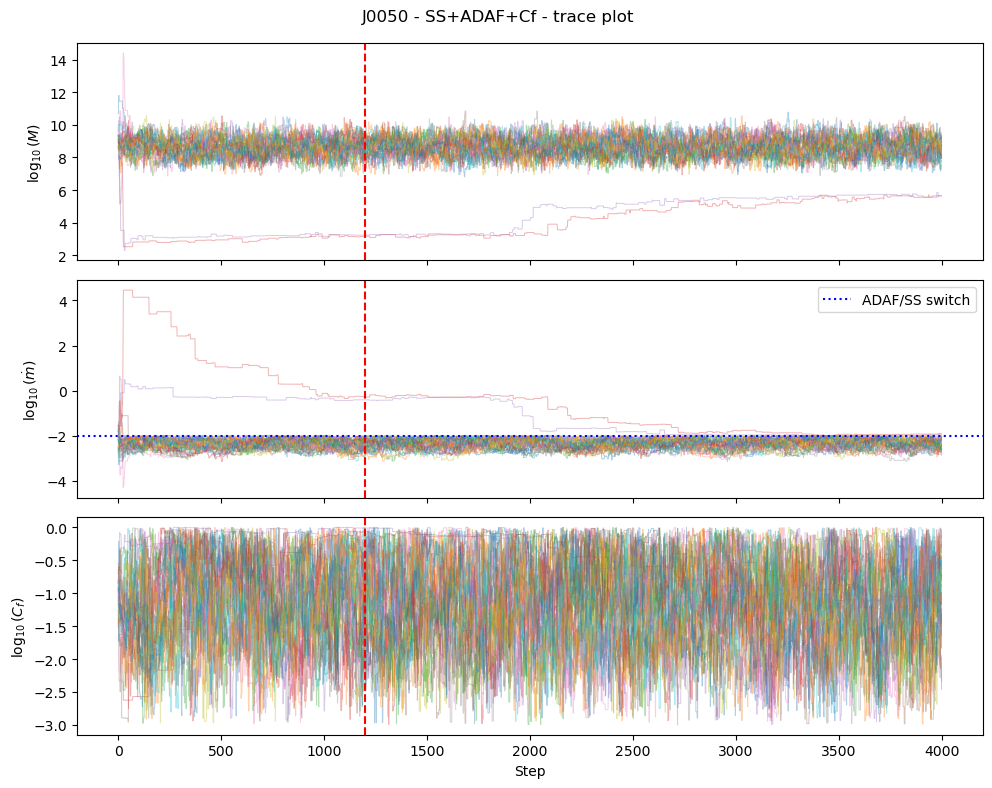

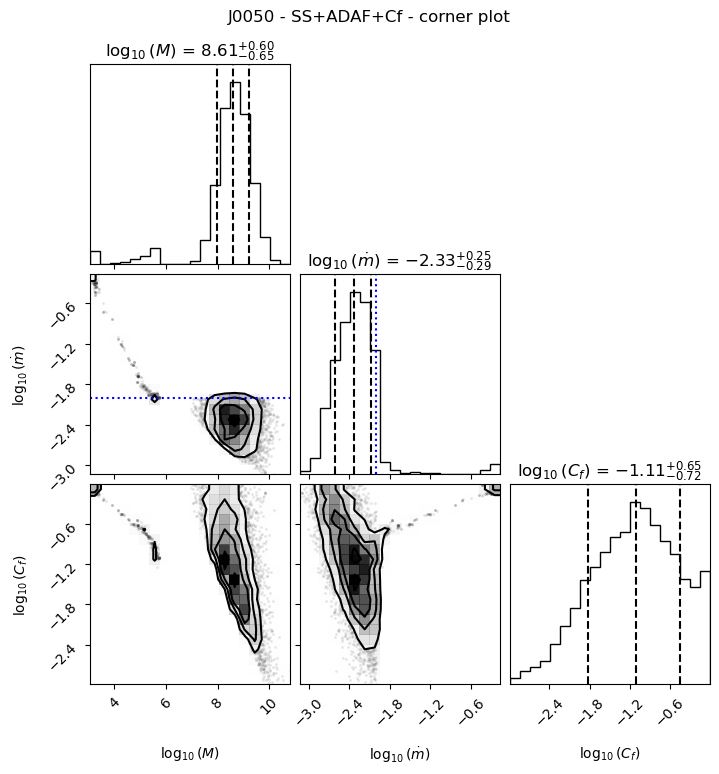

In [207]:
CFG = {
    # Data files
    "line_file": "Tab_completa_revisione.csv",
    "transition_file": "dati.asc",

    # Target blazar
    "label_target": "J0050",

    # ADAF / SS transition switch
    "logmdot_switch": -2.0,

    # Gaussian priors on M and mdot
    "prior_logm_mu": 8.6,
    "prior_logm_sigma": 0.6,
    "prior_logmdot_mu": -1.9,
    "prior_logmdot_sigma": 0.4,

    # Uniform prior on log10(Cf)
    # Cf between 10^-3 and 1
    "logcf_min": -3.0,
    "logcf_max": 0.0,

    # SS physical parameters
    "eta": 0.083,
    "Nr": 80,
    "Nnu_ss": 120,
    "nu_min_ss": 1e13,
    "nu_max_ss": 1e17,

    # ADAF physical parameters
    "alfa": 0.3,
    "rmin": 3.0,
    "rmax": 1000.0,
    "delta": 0.0,
    "beta_adaf": 0.5,
    "c1": 0.5,
    "c3": 0.3,
    "tnorm": 1.68e-10,
    "Nnu_adaf": 120,
    "nu_min_adaf": 1e10,
    "nu_max_adaf": 1e17,
    "root_y0": [0.5, 1.0, 0.99],
    "root_tol": 1e-10,

    # Ionizing luminosity
    "nu_max_ion": 1e17,

    # Relative error if the observed uncertainty is missing
    "rel_err": 0.20,

    # MCMC parameters
    "nwalkers": 32,
    "nsteps": 4000,
    "burn_in": 1200,
    "thin": 15,

    # Walker initialization
    "guess_logm": 9.0,
    "guess_logmdot": -2.0,
    "guess_logcf": -1.0,
    "spread_logm": 0.5,
    "spread_logmdot": 0.5,
    "spread_logcf": 0.4,

    # Random seed
    "random_seed": 42,
}


# RUN THE FITTING PROCEDURE
result_unified = fit_blazar_unified_mcmc(CFG)